In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.cluster.hierarchy import dendrogram
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, to_hex
import pandas as pd

color_df = pd.read_csv("cluster_to_color.csv")
cluster_to_color = dict(zip(color_df["Cluster"].astype(str), color_df["Color"]))

# Load MATLAB linkage matrix
Z = np.loadtxt(r"Y:\Members\Mia-Sanjana-Hadent\Processed Data\wildtype_062425_011725_9\Altogether Clustering\linkage_matlab.csv", delimiter=",")

threshold = Z[0,0]
Z = Z[1:,:]
def add_sample_counts(Z):
    """
    Add the 4th column (cluster sizes) required by SciPy dendrogram.
    Assumes Z is (n-1, 3) with 0-based indices.
    """
    Z = Z.copy()
    n = Z.shape[0] + 1

    counts = np.zeros(Z.shape[0], dtype=int)

    for i in range(Z.shape[0]):
        c1, c2 = int(Z[i, 0]), int(Z[i, 1])

        def cluster_size(c):
            if c < n:
                return 1
            else:
                return counts[c - n]

        counts[i] = cluster_size(c1) + cluster_size(c2)

    return np.column_stack([Z, counts])


# Convert MATLAB (1-based) → Python (0-based)
Z[:, 0:2] -= 1

# Add 4th column
Z = add_sample_counts(Z)

In [2]:
df = pd.read_csv(r"D:\from desktop\Hadents Folder\Visualization\Output_test_wildtype\data\combined_results_wildtype_with_features.csv")

Z_levels = Z.copy()
max_distance = np.max(Z[:, 2])
custom_thresholds = np.linspace(threshold, max_distance*0.5, 4, endpoint=False)
custom_thresholds = np.sort(custom_thresholds)

# Assign each merge to a level 1–5 based on custom thresholds
for i in range(Z_levels.shape[0]):
    dist = Z_levels[i, 2]
    level = np.sum(dist > custom_thresholds) + 1  # level from 1 to 5
    Z_levels[i, 2] = level

n = Z.shape[0] + 1
leaf_labels = np.arange(1, n+1)

In [3]:
def get_dendogram_color_data(dendrogram_data, all_segments):
    leaf_order = dendrogram_data['leaves']
    leaf_x_positions = []

    for seg in all_segments:
        if np.any(np.isclose(seg[:, 1], 0)):
            bottom_points = seg[np.isclose(seg[:, 1], 0)]
            for pt in bottom_points:
                leaf_x_positions.append(pt[0])

    leaf_x_positions = np.array(leaf_x_positions)
    unique_x = np.unique(leaf_x_positions)
    sort_idx = np.argsort(unique_x)
    leaf_x_positions = unique_x[sort_idx]

    df_leaf_colors = pd.DataFrame({
        "LeafIndex": leaf_order,
        "ClusterLabel": np.array(leaf_order) + 1,
        "XPosition": leaf_x_positions,
    })

    df_leaf_colors["HEX_Color"] = df_leaf_colors["ClusterLabel"].apply(
        lambda c: cluster_to_color.get(str(c), "#aaaaaa")
    )
    df_leaf_colors["RGBA_Color"] = df_leaf_colors["HEX_Color"].apply(
        lambda h: matplotlib.colors.to_rgba(h)
    )

    return df_leaf_colors

In [4]:
stages = []
week_numbers = df["Week_Number"].unique()

for week in week_numbers:
    week_data = df[df["Week_Number"] == week]
    stages.append(week_data)

In [9]:
def dendogram_plot_combined_stages(save_path, stages, fixed_max=None):
    """
    Plot one dendrogram with 5 bar graphs (one per stage) stacked below it.
    All bar graphs share the same x-axis aligned to dendrogram leaves.
    Bars exceeding fixed_max are clipped and annotated with their actual value.
    """
    n_stages = len(stages)

    height_ratios = [4] + [1.2] * n_stages
    fig, axes = plt.subplots(
        n_stages + 1, 1,
        figsize=(18, 4 + n_stages * 1.8),
        gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.05},
        sharex=True
    )

    ax_dendro = axes[0]
    ax_bars = axes[1:]

    # -------------------------
    # DENDROGRAM
    # -------------------------
    ddata = dendrogram(Z_levels, ax=ax_dendro, labels=leaf_labels)

    line_collections = [c for c in ax_dendro.collections if isinstance(c, LineCollection)]

    all_segments = []
    segment_map = []
    for lc in line_collections:
        for seg in lc.get_segments():
            all_segments.append(seg)
            segment_map.append(lc)

    vertical_indices = []
    vertical_x = []
    for i, seg in enumerate(all_segments):
        if np.allclose(seg[0, 0], seg[1, 0]):
            vertical_indices.append(i)
            vertical_x.append(seg[0, 0])

    vertical_x = np.array(vertical_x)
    x_min, x_max = vertical_x.min(), vertical_x.max()
    x_norm = (vertical_x - x_min) / (x_max - x_min)

    cmap = LinearSegmentedColormap.from_list(
        "custom_gradient",
        ["#eec42b", "#61b751", "#2a84df", "#dd077a"]
    )

    

    ax_dendro.spines['bottom'].set_visible(False)
    ax_dendro.set_ylabel("Hierarchy Level")
    ax_dendro.set_yticks(range(1, 6))
    ax_dendro.set_yticklabels(list(range(5, 0, -1)))
    ax_dendro.set_title("5-Level Hierarchy Dendrogram — All Stages")
    ax_dendro.tick_params(axis='x', length=0, labelsize=6)

    df_leaf_colors = get_dendogram_color_data(ddata, all_segments)
    
    # Remove the cmap gradient block and replace with:
    level_colors = {
    1: "#eec42b",
    2: "#61b751", 
    3: "#2a84df",
    4: "#dd077a",
    5: "#9b59b6"
    }
    # Color each segment by its y-height (which is the level in Z_levels)
    
    final_colors = []
    for seg in all_segments:
        max_y = max(seg[:, 1])
        min_y = min(seg[:, 1])
        
        if False:
            # Leaf segment — color by cluster
            x_val = seg[0, 0]  # x position of this leaf
            # Find closest leaf x position to get cluster label
            closest_idx = np.argmin(np.abs(df_leaf_colors["XPosition"].values - x_val))
            cluster_label = df_leaf_colors.iloc[closest_idx]["ClusterLabel"]
            hex_color = cluster_to_color.get(str(cluster_label), "#aaaaaa")
            final_colors.append(matplotlib.colors.to_rgba(hex_color))
        else:
            # Internal segment — color by level
            level = int(round(max_y))
            final_colors.append(level_colors.get(level, (0.7, 0.7, 0.7, 1)))

    bar_colors = df_leaf_colors["RGBA_Color"].tolist()
    
    # Apply colors back to line collections
    start = 0
    for lc in line_collections:
        lc.set_linewidth(2)
        seg_count = len(lc.get_segments())
        lc.set_color(final_colors[start:start + seg_count])
        start += seg_count

    leaf_order = ddata['leaves']
    x_positions = np.arange(len(leaf_order)) * 10 + 5

    # -------------------------
    # BAR GRAPHS — one per stage
    # -------------------------
    global_max = 0
    all_bar_values = []

    for stage_df in stages:
        cluster_counts = stage_df.groupby('Cluster').size()
        cluster_percent = cluster_counts / cluster_counts.sum() * 100
        bar_values = []
        for label in leaf_order:
            cluster_label = label + 1
            bar_values.append(cluster_percent.get(cluster_label, 0))
        all_bar_values.append(bar_values)
        global_max = max(global_max, max(bar_values))

    if fixed_max is not None:
        global_max = fixed_max

    y_limit = global_max * 1.15

    for i, (ax_bar, bar_values, stage_df) in enumerate(zip(ax_bars, all_bar_values, stages)):
        for x, val, color in zip(x_positions, bar_values, bar_colors):
            if fixed_max is not None and val > fixed_max:
                bar_end = y_limit * 0.85

                # Draw clipped bar
                ax_bar.bar(x, bar_end, width=8, color=color)

                # Draw zigzag break lines at the clipped edge
                bar_half = 3  # half of bar width=8
                zz_amp = 0.3  # zigzag amplitude (in x units)
                zz_y_step = bar_end * 0.06 # zigzag height as fraction of axis

                # Two offset zigzag lines to make a "cut" symbol
                for x_offset in [-bar_half * 0.3, bar_half * 0.3]:
                    zx = [
                        x - bar_half + x_offset,
                        x - bar_half * 0.3 + x_offset + zz_amp,
                        x + bar_half * 0.3 + x_offset - zz_amp,
                        x + bar_half + x_offset
                    ]
                    zy = [
                        bar_end * 0.9 - zz_y_step,
                        bar_end * 0.9 - zz_y_step * 2,
                        bar_end * 0.9 - zz_y_step * 0,
                        bar_end * 0.9 - zz_y_step
                    ]
                    ax_bar.plot(zx, zy, color='white', linewidth=1.2, solid_capstyle='round')

                # Value label
                ax_bar.text(
                    x, bar_end * 1.05,
                    f"{val:.1f}",
                    ha='center', va='top',
                    fontsize=5, fontweight='light', color='black'
                )
            else:
                ax_bar.bar(x, val, width=8, color=color)

        ax_bar.set_ylim(0, y_limit)
        ax_bar.invert_yaxis()
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.spines['bottom'].set_visible(False)
        ax_bar.set_ylabel(f"Stage {i+1}\n(Cluster %)", fontsize=8, rotation=90, labelpad=10, va='center')
        ax_bar.tick_params(axis='x', labelsize=6, rotation=90)
        ax_bar.tick_params(axis='y', labelsize=7)
        ax_bar.yaxis.set_major_locator(plt.MaxNLocator(2, integer=False))

    fig.savefig(save_path, dpi=300, bbox_inches='tight', format='png')
    plt.tight_layout()
    plt.show()
    print(f"Saved to {save_path}")
    return df_leaf_colors

C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_47596\2538669546.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


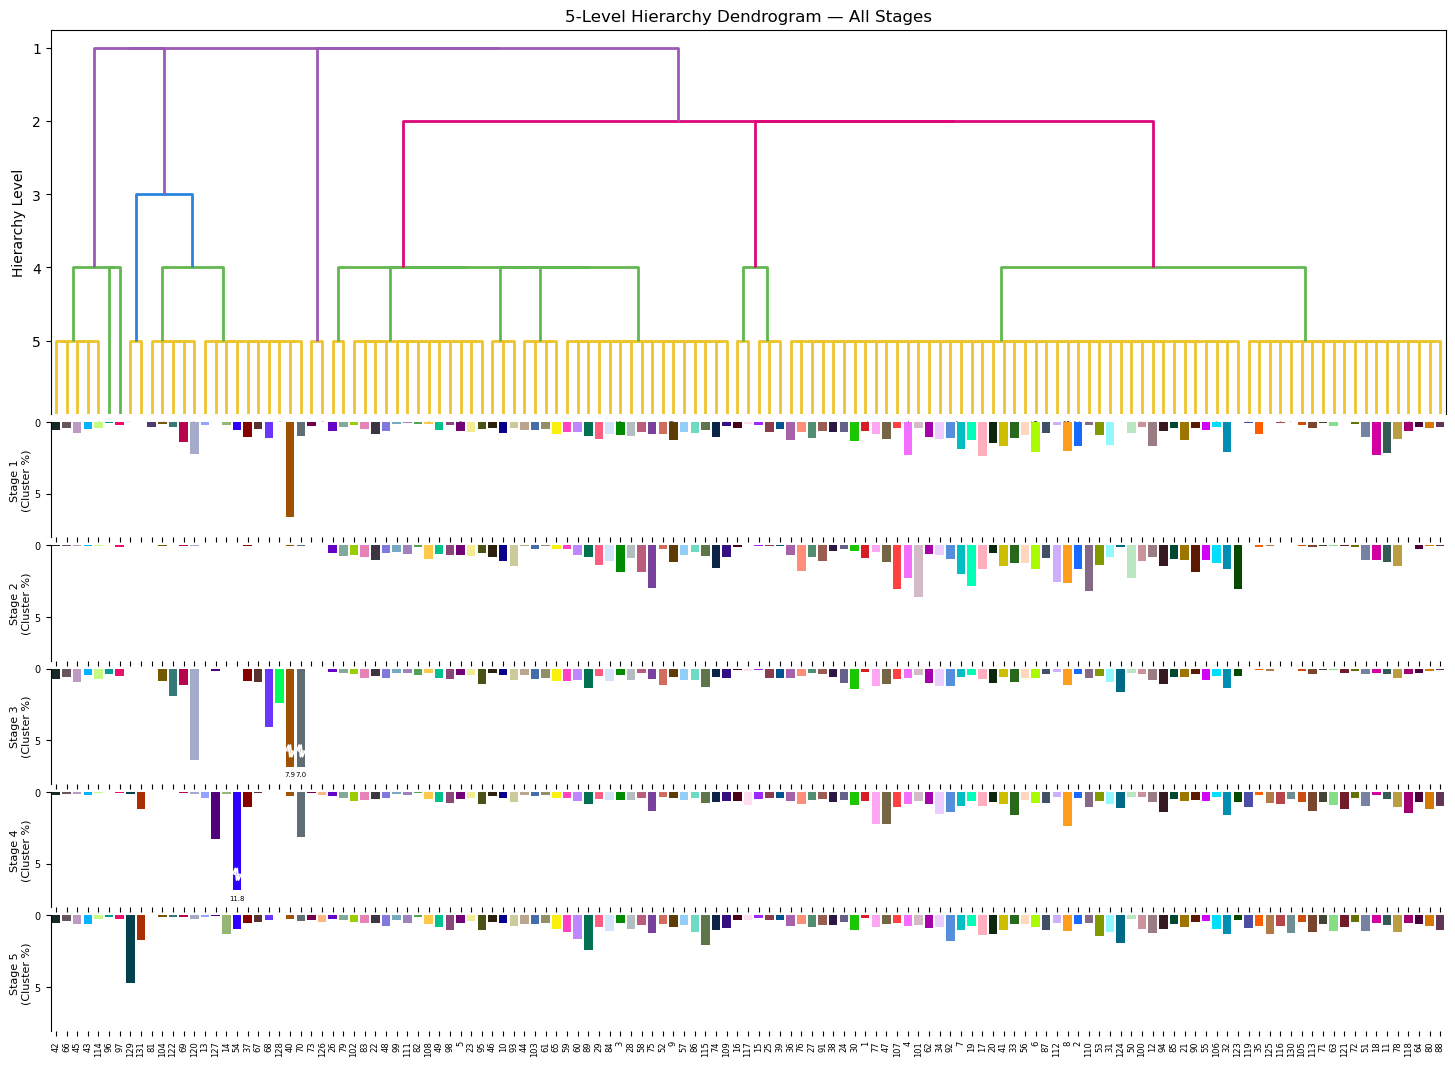

Saved to Hierarchy_Dendogram_All_Stages.png


In [10]:
df_leaf_colors = dendogram_plot_combined_stages("Hierarchy_Dendogram_All_Stages.png", stages, fixed_max=7)

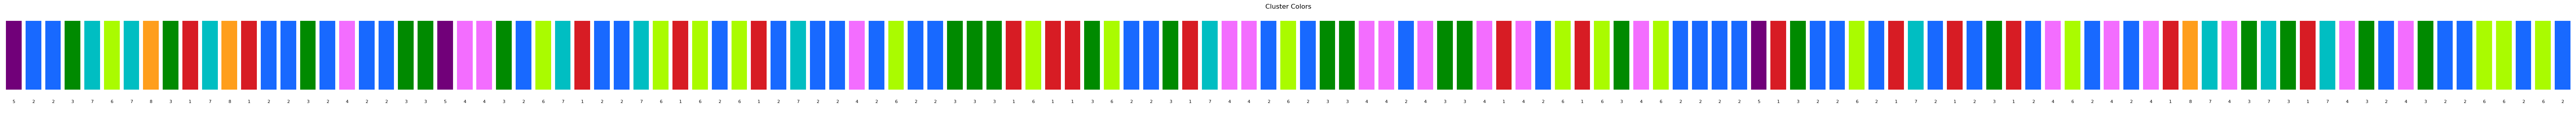

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

color_df = pd.read_csv("cluster_to_color.csv")
color_df = df_leaf_colors
fig, ax = plt.subplots(figsize=(max(6, len(color_df) * 0.5), 3))

for i, row in color_df.iterrows():
    ax.bar(i, 1, color=row["HEX_Color"], width=0.8)
    ax.text(i, -0.15, str(row["ClusterLabel"]), ha='center', va='top', fontsize=8)

ax.set_xlim(-0.5, len(color_df) - 0.5)
ax.set_ylim(-0.3, 1.1)
ax.axis('off')
ax.set_title("Cluster Colors", fontsize=12, pad=10)

plt.tight_layout()
plt.savefig("cluster_colors.png", dpi=150, bbox_inches='tight')
plt.show()